In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras import layers
from keras.layers import Dense,Flatten,Conv2D,Dropout,BatchNormalization,GlobalAveragePooling2D,MaxPooling2D,Input,Rescaling

In [5]:
train_ds=keras.utils.image_dataset_from_directory(
    directory='/kaggle/input/datasets/bhaveshmittal/melanoma-cancer-dataset/train',
    labels='inferred',
    label_mode='int',
    validation_split=0.2,
    subset="training",
    seed=123,
    batch_size=32,
    image_size=(224,224)
)
validation_ds=keras.utils.image_dataset_from_directory(
    directory='/kaggle/input/datasets/bhaveshmittal/melanoma-cancer-dataset/train',
    labels='inferred',
    label_mode='int',
    validation_split=0.2,
    subset="validation",
    seed=123,
    batch_size=32,
    image_size=(224,224)
)
test_ds=keras.utils.image_dataset_from_directory(
    directory='/kaggle/input/datasets/bhaveshmittal/melanoma-cancer-dataset/test',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(224,224)
)

Found 11879 files belonging to 2 classes.
Using 9504 files for training.
Found 11879 files belonging to 2 classes.
Using 2375 files for validation.
Found 2000 files belonging to 2 classes.


In [6]:
# num of batches
print("In train_ds",len(train_ds))
print("In validation_ds",len(validation_ds))

In train_ds 297
In validation_ds 75


In [7]:
# num of images
train_count = sum(1 for _ in train_ds.unbatch())
val_count = sum(1 for _ in validation_ds.unbatch())

print("Train images:", train_count)
print("Validation images:", val_count)

Train images: 9504
Validation images: 2375


In [8]:
import numpy as np
train_label=np.concatenate([y.numpy() for x,y in train_ds])
validation_label=np.concatenate([y.numpy() for x,y in validation_ds])
print("train label ",np.bincount(train_label))
print("validation label ",np.bincount(validation_label))

train label  [5047 4457]
validation label  [1242 1133]


In [9]:
# Check Class Balance
train_distribution=np.bincount(train_label)
print("For Train_ds",train_distribution/train_distribution.sum())
validation_distribution=np.bincount(validation_label)
print("For validation_ds",validation_distribution/validation_distribution.sum())

For Train_ds [0.53103956 0.46896044]
For validation_ds [0.52294737 0.47705263]


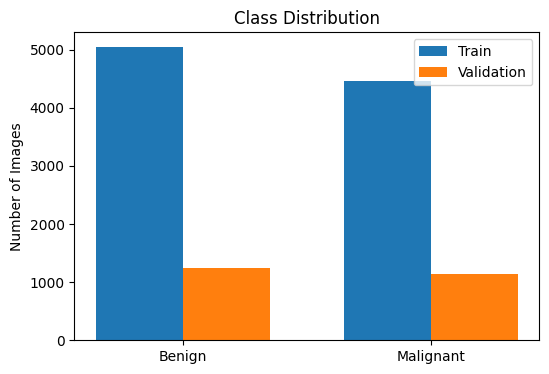

In [11]:
# Get distributions

classes = ["Benign", "Malignant"]

x = np.arange(len(classes))
width = 0.35

plt.figure(figsize=(6,4))
plt.bar(x - width/2, train_distribution, width, label="Train")
plt.bar(x + width/2, validation_distribution, width, label="Validation")

plt.xticks(x, classes)
plt.ylabel("Number of Images")
plt.title("Class Distribution")
plt.legend()
plt.show()

In [12]:
AUTOTUNE=tf.data.AUTOTUNE
train_ds=train_ds.prefetch(AUTOTUNE)
validation_ds=validation_ds.prefetch(AUTOTUNE)

In [ ]:
model=Sequential()
model.add(Rescaling(1./255, input_shape=(224,224,3)))
model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.4))

model.add(Dense(1,activation='sigmoid'))



In [21]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,985 (42.61 MB)

 Trainable params: 11,169,537 (42.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [23]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [24]:
history=model.fit(train_ds,epochs=10,validation_data=validation_ds)

Epoch 1/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 24s 66ms/step - accuracy: 0.7499 - loss: 5.4003 - val_accuracy: 0.5608 - val_loss: 13.1696
Epoch 2/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 19s 64ms/step - accuracy: 0.8198 - loss: 0.5623 - val_accuracy: 0.8383 - val_loss: 0.5127
Epoch 3/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 19s 65ms/step - accuracy: 0.8488 - loss: 0.3843 - val_accuracy: 0.8383 - val_loss: 0.3654
Epoch 4/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 19s 64ms/step - accuracy: 0.8567 - loss: 0.3409 - val_accuracy: 0.8678 - val_loss: 0.3355
Epoch 5/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 19s 63ms/step - accuracy: 0.8526 - loss: 0.3177 - val_accuracy: 0.8265 - val_loss: 0.4000
Epoch 6/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 19s 64ms/step - accuracy: 0.8571 - loss: 0.3483 - val_accuracy: 0.7461 - val_loss: 0.6029
Epoch 7/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 19s 64ms/step - accuracy: 0.8495 - loss: 0.3703 - val_accuracy: 0.7044 - val_loss: 1.3415
Epoch 8/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 19s 64ms/step - accuracy: 0.8528 - loss: 0.3760 -

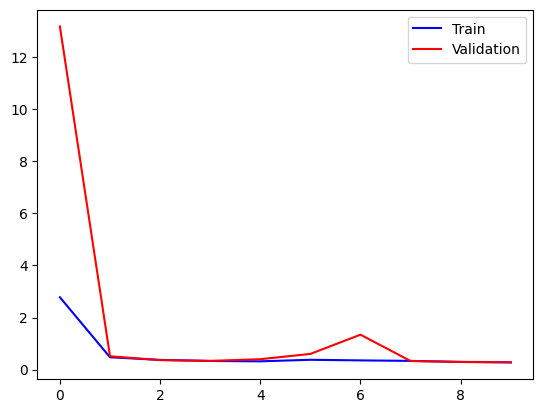

In [25]:
plt.plot(history.history['loss'],color='blue',label='Train')
plt.plot(history.history['val_loss'],color='red',label='Validation')
plt.legend()
plt.show()

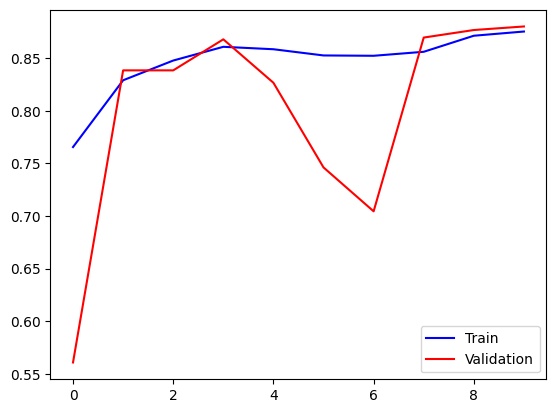

In [26]:
plt.plot(history.history['accuracy'],color='blue',label='Train')
plt.plot(history.history['val_accuracy'],color='red',label='Validation')
plt.legend()
plt.show()

In [27]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - accuracy: 0.8824 - loss: 0.2790
Test Accuracy: 0.8784999847412109
Test Loss: 0.2834394574165344


In [50]:
from sklearn.metrics import classification_report, confusion_matrix

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    preds = (preds > 0.4).astype(int)
    
    y_true.extend(labels.numpy())
    y_pred.extend(preds.flatten())

cs=classification_report(y_true, y_pred)
print(cs)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━

In [51]:
cm=confusion_matrix(y_true,y_pred)
print(cm)

[[886 114]
 [ 87 913]]


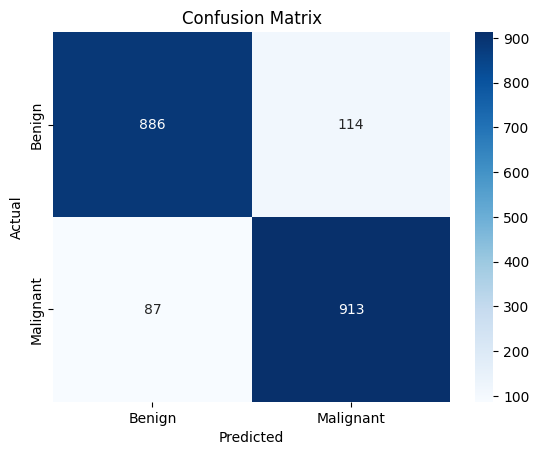

In [52]:
import seaborn as sns
sns.heatmap(cm,fmt='d',annot=True,cmap='Blues',xticklabels=["Benign", "Malignant"],yticklabels=["Benign", "Malignant"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [54]:
y_true2 = np.array(y_true)
y_scores2 = np.array(y_pred)

In [56]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_true2, y_scores2)
roc_auc = auc(fpr, tpr)

print("AUC:", roc_auc)

AUC: 0.8995000000000001


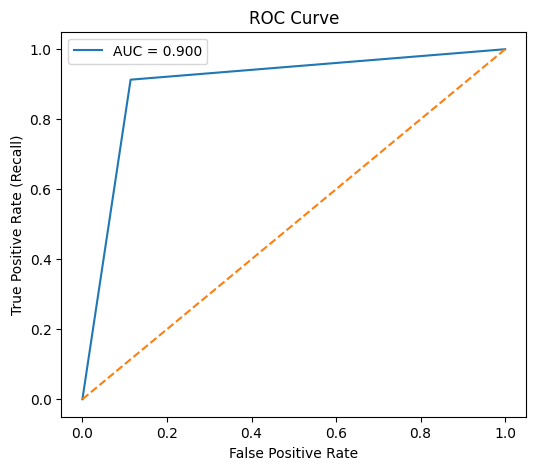

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')  # random classifier line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [58]:
model.save("melanoma_model.h5")